In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 周波数エネルギー（帯域別）

In [2]:
img = cv2.imread('sample.bmp', cv2.IMREAD_GRAYSCALE)

In [3]:
def compute_band_energy(image, bands=((0, 0.1), (0.1, 0.3), (0.3, 0.5))):
    """
    周波数帯域ごとのエネルギーを辞書で返す
    """
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift) ** 2

    h, w = image.shape
    cy, cx = h // 2, w // 2
    max_radius = np.sqrt(cx**2 + cy**2)

    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    freq_norm = dist / max_radius / 2

    total_energy = np.sum(magnitude)
    energies = {}

    for i, (fmin, fmax) in enumerate(bands):
        mask = (freq_norm >= fmin) & (freq_norm < fmax)
        energy = np.sum(magnitude[mask]) / total_energy
        band_key = f"band_{i+1}_{fmin:.2f}_{fmax:.2f}"
        energies[band_key] = energy

    return energies


 ## スペクトル重心（Spectral Centroid)
-   全周波数の強度の加重平均

In [18]:
def compute_spectral_centroid(image, show_freq_map=False):
    """
    2D画像のスペクトル重心を計算し、正規化空間周波数マップをブルー系で可視化する。
    """
    h, w = image.shape
    cy, cx = h // 2, w // 2

    # 2D FFTとスペクトル
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)

    # 正規化周波数マップの作成
    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    max_radius = np.sqrt(cx**2 + cy**2)
    norm_freq = dist / max_radius / 2

    # スペクトル重心の計算
    numerator = np.sum(norm_freq * magnitude)
    denominator = np.sum(magnitude)
    centroid = numerator / denominator if denominator != 0 else 0

    if show_freq_map:
        plt.imshow(norm_freq, cmap='winter')
        plt.colorbar(label='Normalized Frequency (0 to 0.5)')
        plt.title("Normalized Frequency Map (Blue)")
        plt.xlabel("X-axis (pixels)")
        plt.ylabel("Y-axis (pixels)")
        plt.tight_layout()
        plt.show()

    return centroid

## 高周波／低周波の比率（High / Low Frequency Ratio）

In [38]:
def compute_high_low_freq_ratio(image, threshold=0.2):
    h, w = image.shape
    cy, cx = h // 2, w // 2
    max_radius = np.sqrt(cx**2 + cy**2)

    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)**2  # パワースペクトル

    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    norm_freq = dist / max_radius / 2  # 0〜0.5

    low_mask = norm_freq < threshold
    high_mask = norm_freq >= threshold

    low_energy = np.sum(magnitude[low_mask])
    high_energy = np.sum(magnitude[high_mask])

    return high_energy / low_energy if low_energy > 0 else np.inf


## スペクトルの分散 / 標準偏差

In [39]:
def compute_spectral_std(image):
    h, w = image.shape
    cy, cx = h // 2, w // 2
    max_radius = np.sqrt(cx**2 + cy**2)

    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)

    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((x - cx)**2 + (y - cy)**2)
    norm_freq = dist / max_radius / 2

    weights = magnitude
    mean = np.sum(norm_freq * weights) / np.sum(weights)
    var = np.sum(((norm_freq - mean)**2) * weights) / np.sum(weights)
    return np.sqrt(var)


## 方向性エネルギー（Directional Energy）水平

In [40]:
def compute_directional_energy(image, angle_deg=0, tolerance_deg=10):
    h, w = image.shape
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)**2

    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    dy = y - cy
    dx = x - cx
    angle = np.arctan2(dy, dx) * 180 / np.pi  # -180〜180度

    angle = (angle + 360) % 180  # 0〜180度に正規化
    diff = np.abs(angle - angle_deg)
    mask = diff <= tolerance_deg

    directional_energy = np.sum(magnitude[mask])
    total_energy = np.sum(magnitude)
    return directional_energy / total_energy


## スペクトルピーク数／最大値

In [41]:
from scipy.ndimage import maximum_filter

def compute_spectral_peaks(image, threshold_ratio=0.1):
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)

    # 局所ピークを検出
    max_local = maximum_filter(magnitude, size=3)
    peaks = (magnitude == max_local) & (magnitude > magnitude.max() * threshold_ratio)

    num_peaks = np.sum(peaks)
    max_peak = magnitude.max()

    return num_peaks, max_peak


In [42]:
def extract_fft_features_with_units(image, mm_per_pixel=None):
    features = {}

    # 変換係数（Noneなら pixel単位のまま）
    freq_unit = "cycle/pixel"
    scale = 1.0
    if mm_per_pixel is not None:
        freq_unit = "cycle/mm"
        scale = 1.0 / mm_per_pixel

    # 1. 高周波/低周波エネルギー比（スケール影響なし）
    high_low_ratio = compute_high_low_freq_ratio(image)
    features["high_low_ratio"] = (high_low_ratio, "ratio")

    # 2. スペクトルの分散（標準偏差）
    spectral_std = compute_spectral_std(image) * scale
    features["spectral_std"] = (spectral_std, freq_unit)

    # 3. 方向性エネルギー（水平／垂直）
    horizontal_energy = compute_directional_energy(image, angle_deg=0)
    features["horizontal_energy"] = (horizontal_energy, "ratio")

    vertical_energy = compute_directional_energy(image, angle_deg=90)
    features["vertical_energy"] = (vertical_energy, "ratio")

    # 4. スペクトルピーク数と最大値
    num_peaks, max_peak_amp = compute_spectral_peaks(image)
    features["num_peaks"] = (num_peaks, "count")
    features["max_peak_amp"] = (max_peak_amp, "power")

    # 5. 周波数帯エネルギー
    band_energies = compute_band_energy(image)
    for k, v in band_energies.items():
        features[k] = (v, "ratio")

    # 6. スペクトル重心
    spectral_centroid = compute_spectral_centroid(image) * scale
    features["spectral_centroid"] = (spectral_centroid, freq_unit)

    return features


In [ ]:
features = extract_fft_features_with_units(img, mm_per_pixel=0.050)
for key, (val, unit) in features.items():
    print(f"{key}: {val:.4f} [{unit}]")

high_low_ratio: 0.0052 [ratio]
spectral_std: 2.2859 [cycle/mm]
horizontal_energy: 0.4995 [ratio]
vertical_energy: 0.1032 [ratio]
num_peaks: 7.0000 [count]
max_peak_amp: 34999978.0000 [power]
band_1_0.00_0.10: 0.9831 [ratio]
band_2_0.10_0.30: 0.0159 [ratio]
band_3_0.30_0.50: 0.0010 [ratio]
spectral_centroid: 3.1382 [cycle/mm]


 ## スペクトル重心（Spectral Centroid) 可視化

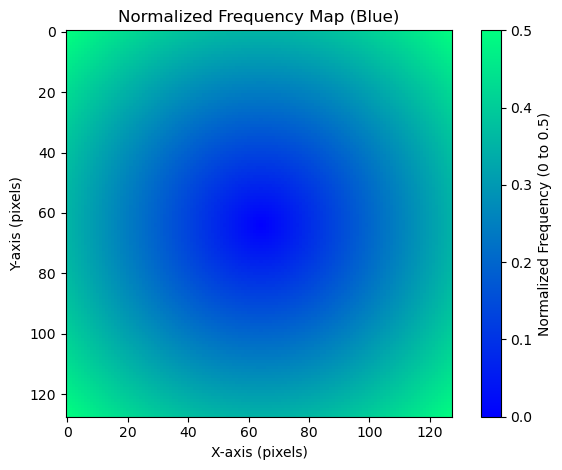

スペクトル重心: 0.1367


In [19]:
image = cv2.imread("sample.bmp", cv2.IMREAD_GRAYSCALE)  # グレースケールで読み込み
image = cv2.resize(image, (128, 128), interpolation=cv2.INTER_AREA)  # リサイズ
image = image.astype(np.float32) / 255.0  # 正規化（0〜1）

centroid = compute_spectral_centroid(image, show_freq_map=True)
print(f"スペクトル重心: {centroid:.4f}")
